In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [2]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = datasets.MNIST(root="data", train=True, download=True, transform=transform)
full_test_dataset = datasets.MNIST(root="data", train=False, download=True, transform=transform)

train_subset= Subset(full_train_dataset, torch.arange(5000))
test_subset= Subset(full_test_dataset, torch.arange(1000))

train_loader= DataLoader(train_subset, batch_size=60, shuffle=True)
test_loader= DataLoader(test_subset, shuffle=True, batch_size=60)

100%|██████████| 9.91M/9.91M [02:02<00:00, 81.2kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 94.6kB/s]
100%|██████████| 1.65M/1.65M [00:14<00:00, 115kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.14MB/s]


In [3]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network= nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

In [16]:
def train_model(model, train_loader, test_loader, optimizer, criterion, epochs=5):
    
    val_accuracies = []
    
    for epoch in range(epochs):
        # Training 
        model.train()
        for batch, (images, labels) in enumerate(train_loader):
            optimizer.zero_grad()          # Zero the gradients
            outputs = model(images)        # Forward pass
            loss = criterion(outputs, labels) # Compute loss
            loss.backward()                # Backpropagate
            optimizer.step()               # Update weights
            
            if batch%100 == 0:
                print(f"Epoch {epoch}, Batch: {batch}, Train Loss: {loss.item():0.2f}")
            
        
        # Evaluation
        model.eval()
        y_pred, y_true = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, predicted = torch.max(outputs, 1)
                y_pred.extend(predicted.numpy())
                y_true.extend(labels.numpy())
        val_accuracy = accuracy_score(y_true, y_pred)
        val_accuracies.append(val_accuracy)
        
    return val_accuracies           

In [17]:
model= MNISTClassifier()
criterion= nn.CrossEntropyLoss()
optimizer= optim.Adam(model.parameters(), lr=0.001)

val_accuracies_no_bn= train_model(model, train_loader, test_loader,  optimizer,criterion, 10)

Epoch 0, Batch: 0, Train Loss: 2.29
Epoch 1, Batch: 0, Train Loss: 0.43
Epoch 2, Batch: 0, Train Loss: 0.46
Epoch 3, Batch: 0, Train Loss: 0.30
Epoch 4, Batch: 0, Train Loss: 0.48
Epoch 5, Batch: 0, Train Loss: 0.12
Epoch 6, Batch: 0, Train Loss: 0.11
Epoch 7, Batch: 0, Train Loss: 0.25
Epoch 8, Batch: 0, Train Loss: 0.13
Epoch 9, Batch: 0, Train Loss: 0.24


In [18]:
print(val_accuracies_no_bn)

[0.811, 0.851, 0.868, 0.879, 0.887, 0.888, 0.892, 0.892, 0.888, 0.905]


In [19]:
class MNISTClassifierWithBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network= nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

In [20]:
model_with_bn= MNISTClassifierWithBN()
criterion_with_bn= nn.CrossEntropyLoss()
optimizer_with_bn= optim.Adam(model_with_bn.parameters(), lr=0.001)

val_accuracies_with_bn= train_model(model_with_bn, train_loader, test_loader,  optimizer_with_bn,criterion_with_bn, 10)

Epoch 0, Batch: 0, Train Loss: 2.48
Epoch 1, Batch: 0, Train Loss: 0.43
Epoch 2, Batch: 0, Train Loss: 0.16
Epoch 3, Batch: 0, Train Loss: 0.06
Epoch 4, Batch: 0, Train Loss: 0.06
Epoch 5, Batch: 0, Train Loss: 0.03
Epoch 6, Batch: 0, Train Loss: 0.04
Epoch 7, Batch: 0, Train Loss: 0.03
Epoch 8, Batch: 0, Train Loss: 0.01
Epoch 9, Batch: 0, Train Loss: 0.04


In [21]:
val_accuracies_with_bn

[0.876, 0.901, 0.9, 0.93, 0.931, 0.926, 0.932, 0.934, 0.927, 0.937]

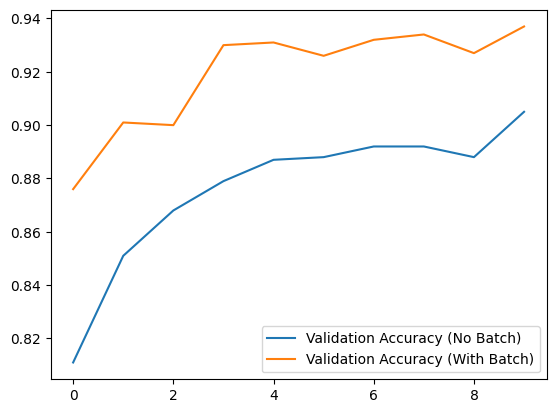

In [22]:
plt.plot(val_accuracies_no_bn, label="Validation Accuracy (No Batch)")
plt.plot(val_accuracies_with_bn, label="Validation Accuracy (With Batch)")
plt.legend()
plt.show()